<a href="https://colab.research.google.com/github/TerePainecura/TRABAJO-HOUSE-PRICES-ml/blob/main/house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [206]:
## 1. Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [207]:
## 2. Carga del dataset desde GitHub
url = "https://raw.githubusercontent.com/TerePainecura/house-prices-ml/main/train.csv"

df = pd.read_csv(url)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [208]:
## 3. Exploración inicial del dataset
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (1460, 81)


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [210]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [211]:
## 4. Verificación de columnas
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [212]:
## 5. Revisión de valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


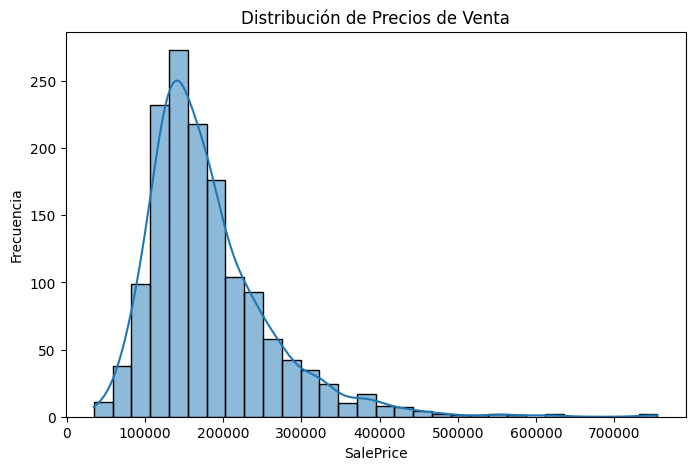

In [213]:
## 6. Análisis de la variable objetivo
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title("Distribución de Precios de Venta")
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.show()

In [214]:
## 7. Transformación logarítmica de la variable objetivo
df["SalePrice_log"] = np.log1p(df["SalePrice"])

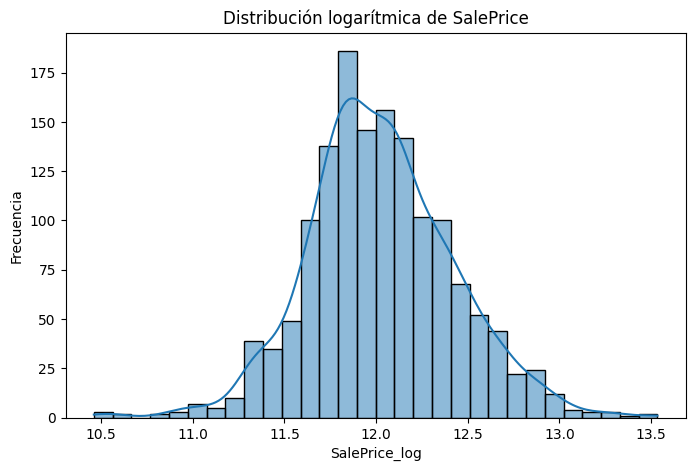

In [215]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice_log'], bins=30, kde=True)
plt.title("Distribución logarítmica de SalePrice")
plt.xlabel("SalePrice_log")
plt.ylabel("Frecuencia")
plt.show()

In [216]:
## 8. Identificación de variables numéricas y categóricas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print("Cantidad de variables categóricas:", len(cat_cols))

Cantidad de variables numéricas: 39
Cantidad de variables categóricas: 43


In [217]:
print("Primeras variables numéricas:", num_cols[:10])
print("Primeras variables categóricas:", cat_cols[:10])

Primeras variables numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']
Primeras variables categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [218]:
## 9. Análisis de valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Cantidad de columnas con valores faltantes:", len(missing))
missing.head(20)

Cantidad de columnas con valores faltantes: 19


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [219]:
## 10. Copia de trabajo para limpieza
df_clean = df.copy()

In [220]:
## 11. Tratamiento de valores faltantes que representan ausencia
cols_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

for col in cols_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("None")

In [221]:
## 12. Imputación de variables numéricas específicas
if "LotFrontage" in df_clean.columns:
    df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["LotFrontage"].median())

In [222]:
## 13. Imputación del resto de variables categóricas
cat_cols_clean = df_clean.select_dtypes(include=["object"]).columns

for col in cat_cols_clean:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [223]:
## 14. Imputación del resto de variables numéricas

num_cols_clean = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols_clean:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [224]:
## 15. Verificación final de valores faltantes
print("Valores faltantes restantes:", df_clean.isnull().sum().sum())

Valores faltantes restantes: 0


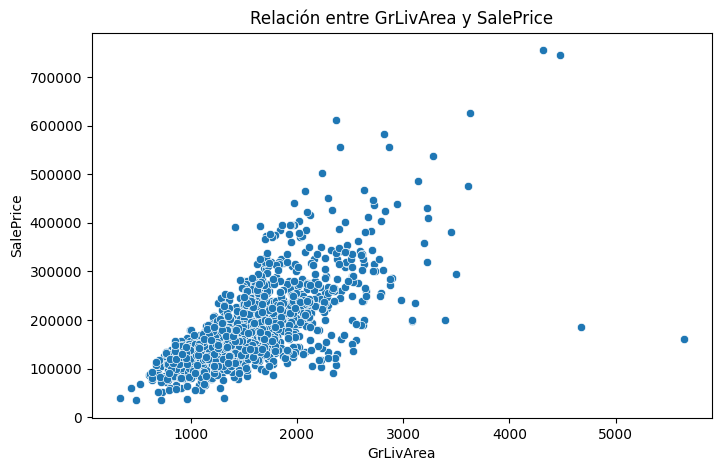

In [225]:
## 16. Identificación de outliers
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean["GrLivArea"], y=df_clean["SalePrice"])
plt.title("Relación entre GrLivArea y SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [226]:
## 17. Tratamiento de outliers extremos
df_clean = df_clean[~((df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 300000))]

print("Dimensiones luego de eliminar outliers:", df_clean.shape)

Dimensiones luego de eliminar outliers: (1458, 82)


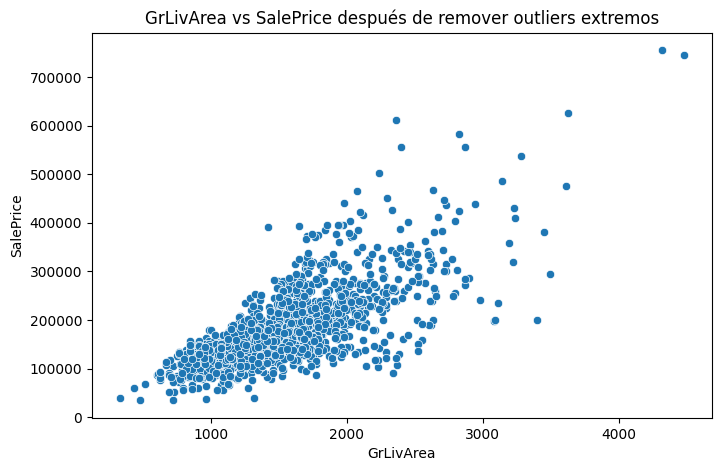

In [227]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean["GrLivArea"], y=df_clean["SalePrice"])
plt.title("GrLivArea vs SalePrice después de remover outliers extremos")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [228]:
## 18. Preparación para la partición de datos
# Asegurar que SalePrice_log exista en la base limpia
df_clean["SalePrice_log"] = np.log1p(df_clean["SalePrice"])

# Variable objetivo
y = df_clean["SalePrice_log"]

# Variables predictoras
X = df_clean.drop(["SalePrice", "SalePrice_log"], axis=1)

In [229]:
## 19. Codificación de variables categóricas
X = pd.get_dummies(X, drop_first=True)
print("Dimensiones de X luego de codificación:", X.shape)

Dimensiones de X luego de codificación: (1458, 249)


In [230]:
## 20. Separación en entrenamiento, validación y test
from sklearn.model_selection import train_test_split

# Primer split: entrenamiento (70%) y temporal (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Segundo split: validación (15%) y test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1020, 249) (1020,)
Validation: (219, 249) (219,)
Test: (219, 249) (219,)


In [231]:
## 21. Interpretación de la partición realizada

# El dataset fue dividido en tres subconjuntos: entrenamiento, validación y prueba.
# El conjunto de entrenamiento se utilizará para ajustar los modelos.
# El conjunto de validación permitirá comparar alternativas y ajustar decisiones metodológicas.
# El conjunto de prueba se reservará para evaluar el desempeño final del modelo en datos no vistos.

In [232]:
## 22. Modelos de Machine Learning

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Definir modelos
models = {
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

# Entrenamiento y evaluación
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)

    results[name] = {
        "RMSE Train": rmse_train,
        "RMSE Val": rmse_val,
        "R2 Train": r2_train,
        "R2 Val": r2_val
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE Train,RMSE Val,R2 Train,R2 Val
Regresión lineal,0.084877,0.132226,0.955174,0.892343
Ridge,0.087712,0.132722,0.952129,0.891534
Lasso,0.104335,0.130118,0.932264,0.895749
Random Forest,0.052683,0.156686,0.982730,0.848830


In [233]:
## 23. Análisis comparativo de generalización

results_df["Gap RMSE"] = results_df["RMSE Val"] - results_df["RMSE Train"]
results_df["Gap R2"] = results_df["R2 Train"] - results_df["R2 Val"]

def comentar_modelo(row):
    if row["Gap RMSE"] > 0.08 or row["Gap R2"] > 0.10:
        return "Posible sobreajuste"
    elif row["RMSE Val"] == results_df["RMSE Val"].min():
        return "Mejor desempeño en validación"
    else:
        return "Desempeño aceptable"

results_df["Comentario"] = results_df.apply(comentar_modelo, axis=1)

results_df = results_df.sort_values(by="RMSE Val")
results_df

,RMSE Train,RMSE Val,R2 Train,R2 Val,Gap RMSE,Gap R2,Comentario
Lasso,0.104335,0.130118,0.932264,0.895749,0.025782,0.036515,Mejor desempeño en validación
Regresión lineal,0.084877,0.132226,0.955174,0.892343,0.047349,0.062831,Desempeño aceptable
Ridge,0.087712,0.132722,0.952129,0.891534,0.045010,0.060595,Desempeño aceptable
Random Forest,0.052683,0.156686,0.982730,0.848830,0.104003,0.133900,Posible sobreajuste


In [234]:
## 24. Optimización de hiperparámetros - Lasso

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

param_grid_lasso = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

grid_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=param_grid_lasso,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Mejor parámetro Lasso:", grid_lasso.best_params_)
print("Mejor score CV Lasso:", grid_lasso.best_score_)

best_lasso = grid_lasso.best_estimator_

# Predicciones
y_pred_train_lasso = best_lasso.predict(X_train)
y_pred_val_lasso = best_lasso.predict(X_val)

# Métricas
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_val_lasso = np.sqrt(mean_squared_error(y_val, y_pred_val_lasso))
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
r2_val_lasso = r2_score(y_val, y_pred_val_lasso)

print("RMSE Train Lasso optimizado:", rmse_train_lasso)
print("RMSE Val Lasso optimizado:", rmse_val_lasso)
print("R2 Train Lasso optimizado:", r2_train_lasso)
print("R2 Val Lasso optimizado:", r2_val_lasso)

Mejor parámetro Lasso: {'alpha': 0.001}
Mejor score CV Lasso: -0.013637243682040362
RMSE Train Lasso optimizado: 0.10433545026899343
RMSE Val Lasso optimizado: 0.13011759970285225
R2 Train Lasso optimizado: 0.9322642777826736
R2 Val Lasso optimizado: 0.8957494784926778


In [239]:
## 25. Optimización de hiperparámetros - Random Forest

from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros Random Forest:", grid_rf.best_params_)
print("Mejor score CV Random Forest:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

# Predicciones
y_pred_train_rf = best_rf.predict(X_train)
y_pred_val_rf = best_rf.predict(X_val)

# Métricas
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_val_rf = r2_score(y_val, y_pred_val_rf)

print("RMSE Train RF optimizado:", rmse_train_rf)
print("RMSE Val RF optimizado:", rmse_val_rf)
print("R2 Train RF optimizado:", r2_train_rf)
print("R2 Val RF optimizado:", r2_val_rf)

Mejores parámetros Random Forest: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor score CV Random Forest: -0.021004139845791223
RMSE Train RF optimizado: 0.06179834692539679
RMSE Val RF optimizado: 0.1541771499641772
R2 Train RF optimizado: 0.9762366484641234
R2 Val RF optimizado: 0.8536319872751397


In [235]:
# Comparación final
final_results = pd.DataFrame({
    "Modelo": ["Lasso optimizado", "Random Forest optimizado"],
    "RMSE Train": [rmse_train_lasso, rmse_train_rf],
    "RMSE Val": [rmse_val_lasso, rmse_val_rf],
    "R2 Train": [r2_train_lasso, r2_train_rf],
    "R2 Val": [r2_val_lasso, r2_val_rf]
})

# Calcular gaps
final_results["Gap RMSE"] = final_results["RMSE Val"] - final_results["RMSE Train"]
final_results["Gap R2"] = final_results["R2 Train"] - final_results["R2 Val"]

final_results

,Modelo,RMSE Train,RMSE Val,R2 Train,R2 Val,Gap RMSE,Gap R2
0,Lasso optimizado,0.104335,0.130118,0.932264,0.895749,0.025782,0.036515
1,Random Forest optimizado,0.061798,0.154177,0.976237,0.853632,0.092379,0.122605


In [236]:
## 26. Modelo XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_val_xgb = xgb_model.predict(X_val)

rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
rmse_val_xgb = np.sqrt(mean_squared_error(y_val, y_pred_val_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
r2_val_xgb = r2_score(y_val, y_pred_val_xgb)

print("RMSE Train XGBoost:", rmse_train_xgb)
print("RMSE Val XGBoost:", rmse_val_xgb)
print("R2 Train XGBoost:", r2_train_xgb)
print("R2 Val XGBoost:", r2_val_xgb)

RMSE Train XGBoost: 0.054450527704709976
RMSE Val XGBoost: 0.1390439188423727
R2 Train XGBoost: 0.9815516231029087
R2 Val XGBoost: 0.8809552769928656


In [237]:
## 27. Red neuronal simple

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Escalamiento de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_train_mlp = mlp_model.predict(X_train_scaled)
y_pred_val_mlp = mlp_model.predict(X_val_scaled)

rmse_train_mlp = np.sqrt(mean_squared_error(y_train, y_pred_train_mlp))
rmse_val_mlp = np.sqrt(mean_squared_error(y_val, y_pred_val_mlp))
r2_train_mlp = r2_score(y_train, y_pred_train_mlp)
r2_val_mlp = r2_score(y_val, y_pred_val_mlp)

print("RMSE Train MLP:", rmse_train_mlp)
print("RMSE Val MLP:", rmse_val_mlp)
print("R2 Train MLP:", r2_train_mlp)
print("R2 Val MLP:", r2_val_mlp)

RMSE Train MLP: 0.08978428747242323
RMSE Val MLP: 0.9877604195229974
R2 Train MLP: 0.9498403315294188
R2 Val MLP: -5.007715926700132


In [238]:
## 28. Comparación final de modelos

final_results = pd.DataFrame({
    "Modelo": [
        "Lasso optimizado",
        "Random Forest optimizado",
        "XGBoost",
        "Red neuronal simple"
    ],
    "RMSE Train": [
        rmse_train_lasso,
        rmse_train_rf,
        rmse_train_xgb,
        rmse_train_mlp
    ],
    "RMSE Val": [
        rmse_val_lasso,
        rmse_val_rf,
        rmse_val_xgb,
        rmse_val_mlp
    ],
    "R2 Train": [
        r2_train_lasso,
        r2_train_rf,
        r2_train_xgb,
        r2_train_mlp
    ],
    "R2 Val": [
        r2_val_lasso,
        r2_val_rf,
        r2_val_xgb,
        r2_val_mlp
    ]
})

final_results["Gap RMSE"] = final_results["RMSE Val"] - final_results["RMSE Train"]
final_results["Gap R2"] = final_results["R2 Train"] - final_results["R2 Val"]

def interpretar_final(row):
    if row["Gap RMSE"] > 0.08 or row["Gap R2"] > 0.10:
        return "Posible sobreajuste"
    elif row["RMSE Val"] == final_results["RMSE Val"].min():
        return "Modelo final recomendado"
    else:
        return "Desempeño intermedio"

final_results["Comentario"] = final_results.apply(interpretar_final, axis=1)

final_results = final_results.sort_values(by="RMSE Val")
final_results

,Modelo,RMSE Train,RMSE Val,R2 Train,R2 Val,Gap RMSE,Gap R2,Comentario
0,Lasso optimizado,0.104335,0.130118,0.932264,0.895749,0.025782,0.036515,Modelo final recomendado
2,XGBoost,0.054451,0.139044,0.981552,0.880955,0.084593,0.100596,Posible sobreajuste
1,Random Forest optimizado,0.061798,0.154177,0.976237,0.853632,0.092379,0.122605,Posible sobreajuste
3,Red neuronal simple,0.089784,0.987760,0.949840,-5.007716,0.897976,5.957556,Posible sobreajuste
